# Introdução ao PLN — Motor1 UOL

Usando as notícias coletadas pelo notebook `web_scraping_motor1.ipynb`  
para aplicar técnicas de Processamento de Linguagem Natural.

Bibliotecas necessárias:
```
pip install pandas nltk unidecode scikit-learn matplotlib
```

In [1]:
!pip install pandas nltk unidecode scikit-learn matplotlib
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from unidecode import unidecode
from nltk.tokenize import wordpunct_tokenize
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   -------------------- ------------------- 0.8/1.6 MB 5.8 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 5.6 MB/s  0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.1 MB 5.3 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.1 MB 5.4 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.1 MB 5.3 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.1 MB 5.6 MB/s eta 0:00:01
   ------------------------------- -------- 6.3/8.1 MB 5.9 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.1 MB 6.0 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 5.7 MB/s  0:00:01
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   - -------------------------------------- 1.6/37.3 MB 7.4 MB/s eta 0:00:05
   --- ------------------------------

True

# Passo 1 — Carregando os dados

Lemos todos os arquivos `.json` da pasta `noticias_motor1/`  
e montamos um DataFrame pandas com uma linha por notícia.

In [2]:
noticias = []

for arquivo in sorted(glob.glob("noticias_motor1/*.json")):
    with open(arquivo, encoding="utf-8") as f:
        noticias.append(json.load(f))

df = pd.DataFrame(noticias)

print(f"Notícias carregadas: {len(df)}")
df.head()

Notícias carregadas: 200


,url,titulo,descricao,categoria,data,texto
0,https://motor1.uol.com.br/news/793479/hyundai-...,Hyundai Ioniq 3 é,"Parte da família Ioniq, novo hatch chega com m...",Oficial,2026-04-20,Seguindo um caminho um tanto diferente de suas...
1,https://motor1.uol.com.br/news/793334/shineray...,Shineray revela a nova SHI 170; veja o preço e...,"Nova urbana da marca, Shineray SHI 170 mira no...",Oficial,2026-04-20,"A Shineray apresentou a SHI 170, nova motocicl..."
2,https://motor1.uol.com.br/news/793364/m1-numbe...,M1 numbers: China já faz carros novos na metad...,Entenda como a inteligência artificial e a fab...,Oficial,2026-04-19,A tradição da indústria indica que criar um ca...
3,https://motor1.uol.com.br/news/793376/omoda-ja...,SEGREDO: Omoda & Jaecoo comprará fábrica da Ja...,Omoda & Jaecoo deve assumir fábrica da Jaguar ...,Oficial,2026-04-19,Mais uma marca chinesa definiu onde produzirá ...
4,https://motor1.uol.com.br/news/793349/novo-hon...,Novo Insight: Honda lança no Japão carro elétr...,Esqueça o sedã híbrido: o novo Honda Insight r...,Oficial,2026-04-18,"Lembra do Honda Insight, aquele híbrido com qu..."


In [3]:
# Remove duplicatas pela URL (caso alguma notícia tenha sido coletada duas vezes)
print(f"Antes da deduplicação: {len(df)}")

df = df.drop_duplicates(subset="url").reset_index(drop=True)

print(f"Depois da deduplicação: {len(df)}")

Antes da deduplicação: 200
Depois da deduplicação: 200


# Passo 2 — Limpeza do texto

Aplicamos a função `limpar_texto` em cada notícia:
1. Tudo em **minúsculas**
2. Remove **acentos** com `unidecode`
3. **Tokeniza** com `wordpunct_tokenize`
4. Mantém só **letras** (remove números e pontuação)

In [4]:
def limpar_texto(texto):
    texto = texto.lower()                      # minúsculas
    texto = unidecode(texto)                   # remove acentos
    tokens = wordpunct_tokenize(texto)         # tokeniza
    tokens = [t for t in tokens if t.isalpha()] # só letras
    return " ".join(tokens)


# Combina título + descrição + texto para ter mais conteúdo por notícia
df["conteudo"] = df["titulo"] + " " + df["descricao"] + " " + df["texto"]
df["conteudo"] = df["conteudo"].fillna("")

df["texto_limpo"] = df["conteudo"].apply(limpar_texto)

# Confere o resultado
print("Original:")
print(df["conteudo"].iloc[0][:200])
print()
print("Limpo:")
print(df["texto_limpo"].iloc[0][:200])

Original:
Hyundai Ioniq 3 é  Parte da família Ioniq, novo hatch chega com missão de concorrer entre elétricos de entrada; sucessor do Veloster aposta no estilo cupê e arquitetura de 400V. Seguindo um caminho um

Limpo:
hyundai ioniq e parte da familia ioniq novo hatch chega com missao de concorrer entre eletricos de entrada sucessor do veloster aposta no estilo cupe e arquitetura de seguindo um caminho um tanto dife


# Passo 3 — Removendo Stopwords

Stopwords são palavras muito comuns que não ajudam na análise  
("de", "o", "para", "com", etc.).

Usamos a lista de stopwords em português do NLTK  
e adicionamos algumas palavras genéricas do domínio automotivo.

In [5]:
# Stopwords do NLTK em português (sem acento, para bater com o texto limpo)
stop_pt = set(unidecode(w) for w in stopwords.words("portuguese"))

# Palavras extras do domínio que não agregam informação
stop_extra = {"carro", "carros", "veja", "novo", "nova", "brasil", "tambem",
              "vai", "ser", "mais", "pode", "tem", "ter", "segundo", "dois",
              "tres", "ate", "sera", "ainda", "ano", "anos", "vez"}

todas_stopwords = stop_pt | stop_extra

print(f"Total de stopwords: {len(todas_stopwords)}")


def remover_stopwords(texto):
    tokens = texto.split()
    tokens = [t for t in tokens if t not in todas_stopwords and len(t) > 2]
    return tokens


df["tokens"] = df["texto_limpo"].apply(remover_stopwords)
df["texto_sem_sw"] = df["tokens"].str.join(" ")

# Confere o resultado
print()
print("Exemplo de tokens (primeiros 15):")
print(df["tokens"].iloc[0][:15])

Total de stopwords: 216

Exemplo de tokens (primeiros 15):
['hyundai', 'ioniq', 'parte', 'familia', 'ioniq', 'hatch', 'chega', 'missao', 'concorrer', 'eletricos', 'entrada', 'sucessor', 'veloster', 'aposta', 'estilo']


# Passo 4 — Análise Exploratória

Antes do PLN, olhamos para os dados para entender o que temos.

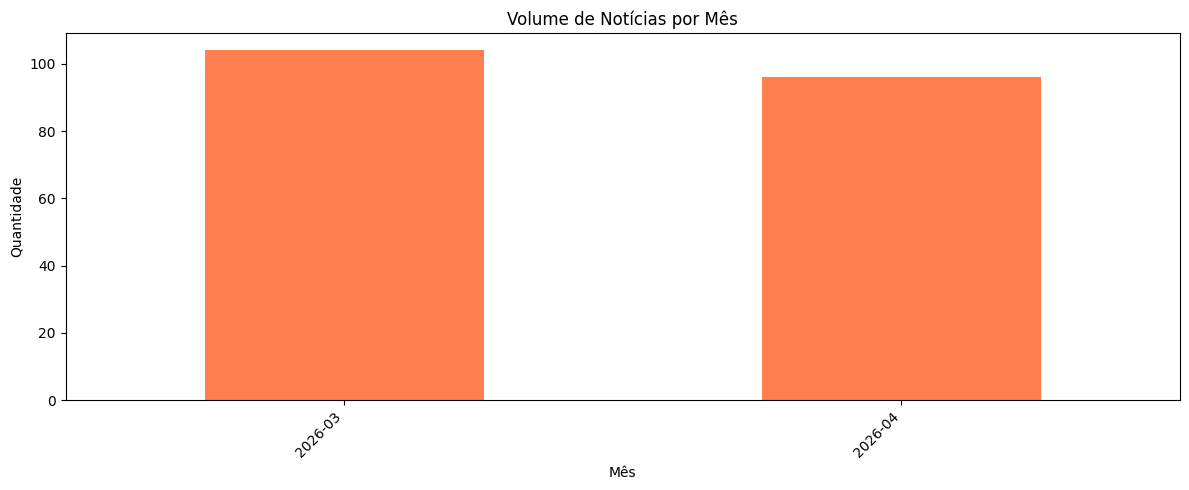

In [7]:
# Notícias por mês
df["data_dt"] = pd.to_datetime(df["data"], errors="coerce")
df["mes"] = df["data_dt"].dt.to_period("M").astype(str)

noticias_por_mes = df["mes"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
noticias_por_mes.plot(kind="bar", color="coral")
plt.title("Volume de Notícias por Mês")
plt.xlabel("Mês")
plt.ylabel("Quantidade")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Passo 5 — Palavras Mais Frequentes

Contamos quantas vezes cada palavra aparece em **todas** as notícias juntas.

In [8]:
from collections import Counter

# Junta todos os tokens de todas as notícias numa lista só
todos_os_tokens = [token for lista in df["tokens"] for token in lista]

contagem = Counter(todos_os_tokens)

print(f"Vocabulário total: {len(contagem)} palavras únicas")
print()
print("Top 20 palavras:")
for palavra, freq in contagem.most_common(20):
    print(f"  {palavra:20s}: {freq}")

Vocabulário total: 10376 palavras únicas

Top 20 palavras:
  marca               : 442
  eletrico            : 412
  modelo              : 389
  byd                 : 359
  motor               : 308
  suv                 : 304
  jeep                : 300
  hyundai             : 287
  quase               : 286
  benz                : 273
  dolphin             : 269
  cupe                : 257
  linha               : 256
  versao              : 255
  modelos             : 249
  sistema             : 248
  muda                : 247
  renegade            : 242
  tela                : 232
  lojas               : 232


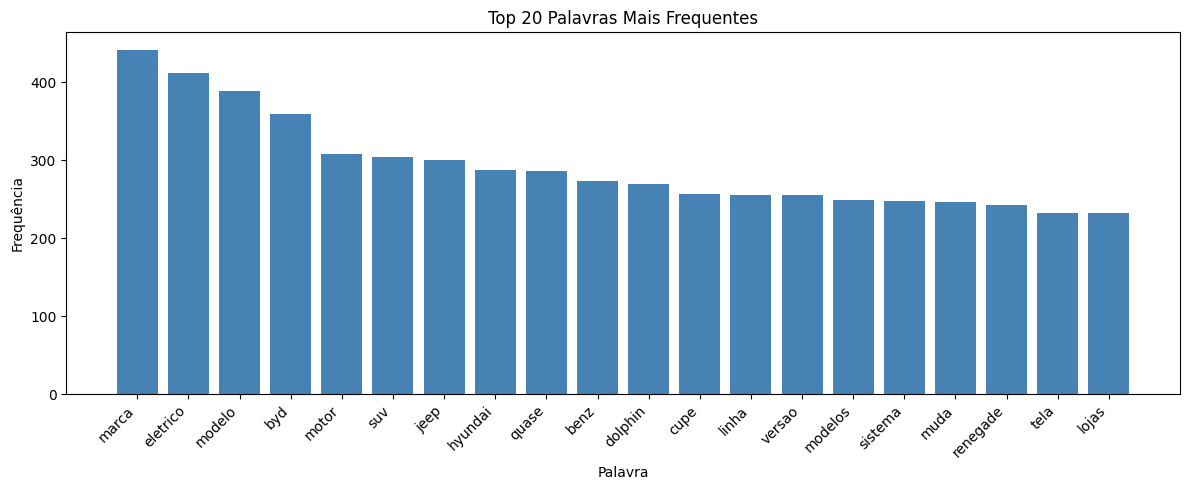

In [9]:
# Gráfico das 20 palavras mais frequentes
top_20 = contagem.most_common(20)
palavras, frequencias = zip(*top_20)

plt.figure(figsize=(12, 5))
plt.bar(palavras, frequencias, color="steelblue")
plt.title("Top 20 Palavras Mais Frequentes")
plt.xlabel("Palavra")
plt.ylabel("Frequência")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Passo 6 — Marcas e Modelos Mais Mencionados

Criamos uma lista de marcas e modelos automotivos  
e verificamos quantas vezes cada um aparece nas notícias.

In [10]:
# Lista de marcas e modelos para buscar (tudo em minúsculas e sem acento)
MARCAS = [
    # Marcas
    "toyota", "volkswagen", "chevrolet", "fiat", "honda", "hyundai",
    "ford", "renault", "jeep", "nissan", "byd", "mercedes", "bmw", "audi",
    "kia", "mitsubishi", "volvo", "peugeot", "citroen", "ram", "geely",
    "gwm", "haval", "chery", "caoa", "jac", "omoda", "jaecoo", "porsche",
    "tesla", "changan", "jetour", "shineray", "leapmotor",
    # Modelos populares no Brasil
    "onix", "strada", "hilux", "corolla", "kwid", "polo", "tera",
    "creta", "tucson", "frontier", "compass", "renegade", "tracker", "toro",
    "dolphin", "song", "seal", "han", "tang", "yunior", "ex",
]

# Conta quantas vezes cada marca aparece no total de tokens
contagem_marcas = Counter()

for tokens in df["tokens"]:
    for token in tokens:
        if token in MARCAS:
            contagem_marcas[token] += 1

print("Marcas/modelos mais mencionados:")
for marca, count in contagem_marcas.most_common(20):
    print(f"  {marca:20s}: {count}")

Marcas/modelos mais mencionados:
  byd                 : 359
  jeep                : 300
  hyundai             : 287
  dolphin             : 269
  renegade            : 242
  fiat                : 155
  toyota              : 144
  renault             : 129
  chevrolet           : 126
  honda               : 111
  nissan              : 99
  bmw                 : 93
  mercedes            : 84
  onix                : 80
  haval               : 78
  gwm                 : 74
  ford                : 69
  changan             : 64
  volkswagen          : 61
  caoa                : 57


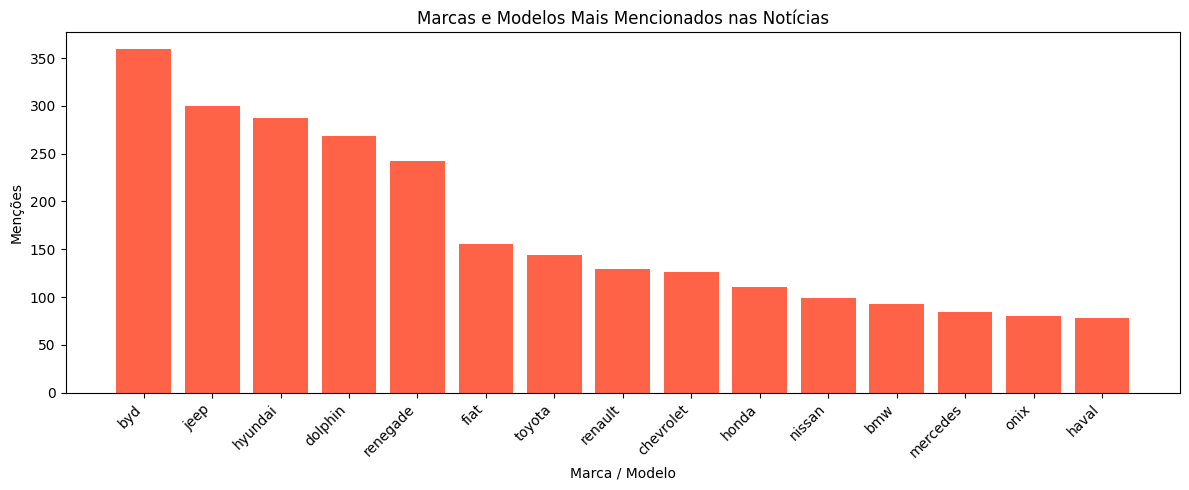

In [11]:
# Gráfico das marcas/modelos mais mencionados
top_marcas = contagem_marcas.most_common(15)
marcas, mencoes = zip(*top_marcas)

plt.figure(figsize=(12, 5))
plt.bar(marcas, mencoes, color="tomato")
plt.title("Marcas e Modelos Mais Mencionados nas Notícias")
plt.xlabel("Marca / Modelo")
plt.ylabel("Menções")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Passo 7 — Bag of Words (BoW)

O Bag of Words transforma cada notícia numa linha de uma tabela,  
onde cada coluna é uma palavra do vocabulário  
e o valor é quantas vezes aquela palavra aparece naquela notícia.

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

# Filtra apenas notícias com texto suficiente
df_valido = df[df["texto_sem_sw"].str.len() > 50].reset_index(drop=True)
print(f"Notícias com texto suficiente: {len(df_valido)}")

# Cria o vetorizador
# max_features=500: considera só as 500 palavras mais frequentes
# min_df=2: ignora palavras que aparecem em menos de 2 notícias
vectorizer = CountVectorizer(max_features=500, min_df=2)

# Transforma o texto em matriz numérica
matriz_bow = vectorizer.fit_transform(df_valido["texto_sem_sw"])

print(f"Vocabulário: {len(vectorizer.get_feature_names_out())} palavras")
print(f"Matriz: {matriz_bow.shape[0]} notícias × {matriz_bow.shape[1]} palavras")

Notícias com texto suficiente: 200
Vocabulário: 500 palavras
Matriz: 200 notícias × 500 palavras


In [13]:
# Transforma a matriz em DataFrame para visualizar
df_bow = pd.DataFrame(
    matriz_bow.toarray(),
    columns=[f"bow_{p}" for p in vectorizer.get_feature_names_out()]
)

# Remove colunas que são só números (como '10', '2026', etc.)
colunas_numericas = [c for c in df_bow.columns if c.replace("bow_", "").isnumeric()]
df_bow = df_bow.drop(columns=colunas_numericas)

print(f"Colunas após remover numéricas: {df_bow.shape[1]}")
df_bow.head()

Colunas após remover numéricas: 500


,bow_abril,bow_acabamento,bow_acima,bow_acordo,bow_agora,bow_alem,bow_alema,bow_algo,bow_alguns,bow_alta,...,bow_versao,bow_versoes,bow_vice,bow_vimos,bow_visual,bow_volante,bow_volkswagen,bow_volta,bow_volume,bow_yaris
0,0,0,1,0,0,0,0,0,1,0,...,1,0,0,1,1,1,0,0,1,0
1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,1,0,0,0,0,0,1,0,0,0,...,0,0,1,1,0,0,0,0,1,0
3,0,0,0,0,3,1,0,0,0,0,...,0,1,1,1,0,0,0,0,2,0
4,0,0,0,0,0,0,0,1,0,0,...,1,1,0,1,0,2,0,1,1,0


In [14]:
# Palavras mais frequentes no vocabulário BoW
freq_total = df_bow.sum().sort_values(ascending=False)

print("Top 10 palavras mais frequentes:")
print(freq_total.head(10))

print()

# Em quantos documentos cada palavra aparece?
docs_com_palavra = (df_bow > 0).sum().sort_values(ascending=False)
print("Top 10 palavras que aparecem em mais documentos:")
print(docs_com_palavra.head(10))

Top 10 palavras mais frequentes:
bow_marca       442
bow_eletrico    412
bow_modelo      389
bow_byd         359
bow_motor       308
bow_suv         304
bow_jeep        300
bow_hyundai     287
bow_quase       286
bow_benz        273
dtype: int64

Top 10 palavras que aparecem em mais documentos:
bow_vimos        200
bow_lojas        200
bow_longitude    200
bow_jeep         200
bow_jeitao       200
bow_benz         200
bow_renegade     200
bow_gostaria     200
bow_quase        200
bow_classe       200
dtype: int64


# Passo 8 — DataFrame Final

Juntamos os metadados (data, categoria, título, URL)  
com as colunas do Bag of Words.

In [15]:
# Metadados da notícia
df_meta = df_valido[["url", "titulo", "categoria", "data"]].reset_index(drop=True)

# Junta com o BoW
df_final = pd.concat([df_meta, df_bow.reset_index(drop=True)], axis=1)

print(f"Shape do DataFrame final: {df_final.shape}")
print(f"Colunas: {list(df_final.columns[:8])} ... (+ {df_final.shape[1]-8} colunas BoW)")

df_final.head()

Shape do DataFrame final: (200, 504)
Colunas: ['url', 'titulo', 'categoria', 'data', 'bow_abril', 'bow_acabamento', 'bow_acima', 'bow_acordo'] ... (+ 496 colunas BoW)


,url,titulo,categoria,data,bow_abril,bow_acabamento,bow_acima,bow_acordo,bow_agora,bow_alem,...,bow_versao,bow_versoes,bow_vice,bow_vimos,bow_visual,bow_volante,bow_volkswagen,bow_volta,bow_volume,bow_yaris
0,https://motor1.uol.com.br/news/793479/hyundai-...,Hyundai Ioniq 3 é,Oficial,2026-04-20,0,0,1,0,0,0,...,1,0,0,1,1,1,0,0,1,0
1,https://motor1.uol.com.br/news/793334/shineray...,Shineray revela a nova SHI 170; veja o preço e...,Oficial,2026-04-20,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
2,https://motor1.uol.com.br/news/793364/m1-numbe...,M1 numbers: China já faz carros novos na metad...,Oficial,2026-04-19,1,0,0,0,0,0,...,0,0,1,1,0,0,0,0,1,0
3,https://motor1.uol.com.br/news/793376/omoda-ja...,SEGREDO: Omoda & Jaecoo comprará fábrica da Ja...,Oficial,2026-04-19,0,0,0,0,3,1,...,0,1,1,1,0,0,0,0,2,0
4,https://motor1.uol.com.br/news/793349/novo-hon...,Novo Insight: Honda lança no Japão carro elétr...,Oficial,2026-04-18,0,0,0,0,0,0,...,1,1,0,1,0,2,0,1,1,0


In [16]:
# Salva o DataFrame final em CSV
df_final.to_csv("motor1_bow.csv", index=False, encoding="utf-8-sig")

print("✅ Salvo: motor1_bow.csv")

✅ Salvo: motor1_bow.csv


# Passo 9 — Palavras Distintas por Categoria

Qual é o vocabulário característico de cada categoria?

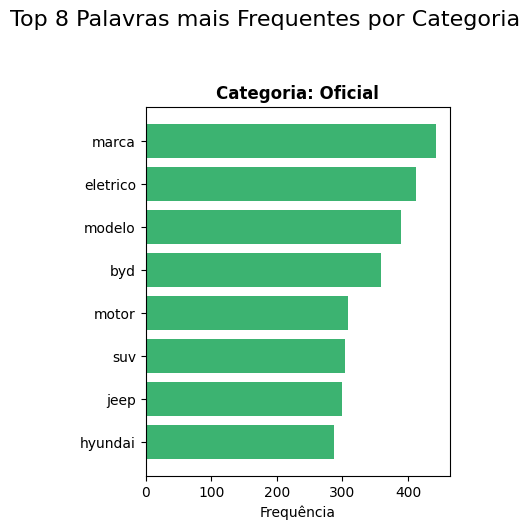

In [20]:
from collections import Counter
import matplotlib.pyplot as plt

# 1. Definição das categorias (Top 5)
top_cats = df_valido["categoria"].value_counts().head(5).index.tolist()
n_cats = len(top_cats)

# 2. Configuração dinâmica dos subplots
fig, axes = plt.subplots(1, n_cats, figsize=(4 * n_cats, 5), sharex=False)

# Garantir que axes seja iterável mesmo se n_cats == 1
if n_cats == 1:
    axes = [axes]

for ax, cat in zip(axes, top_cats):
    # Filtragem e achatamento eficiente de tokens
    subset = df_valido[df_valido["categoria"] == cat]["tokens"]
    tokens_cat = [t for lista in subset for t in lista]

    if not tokens_cat:
        ax.set_title(f"{cat} (Vazio)")
        continue

    # Obtenção dos termos mais frequentes
    top_8 = Counter(tokens_cat).most_common(8)
    lbls, vals = zip(*top_8)

    # Plotagem
    ax.barh(lbls, vals, color="mediumseagreen")
    ax.set_title(f"Categoria: {cat}", fontweight='bold')
    ax.invert_yaxis()  # Deixa a palavra mais frequente no topo
    ax.set_xlabel("Frequência")

plt.suptitle("Top 8 Palavras mais Frequentes por Categoria", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()